EKSPORACYJNA ANALIZA DANYCH spectrogram_stats

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import math
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/PawelMozaryn/CNNs-librosa/refs/heads/main/spectrogram_stats.csv")

In [3]:
df.info()
#sprawdzamy na wszelki wypadek czy napewno nie ma braków danych - jest ok, dane są poprawne

#class imbalance zostało już wcześniej naprawione w pliku 'eda'

#Zawiera 23970 rekordów i 40 kolumn.

#Dane są kompletne (brak wartości NaN w żadnej kolumnie)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            23970 non-null  object 
 1   genre               23970 non-null  object 
 2   mean                23970 non-null  float64
 3   std                 23970 non-null  float64
 4   median              23970 non-null  float64
 5   q25                 23970 non-null  float64
 6   q75                 23970 non-null  float64
 7   q90                 23970 non-null  float64
 8   energy_mean_sq      23970 non-null  float64
 9   sparsity_frac0      23970 non-null  float64
 10  averagefrequency1   23970 non-null  float64
 11  averagefrequency2   23970 non-null  float64
 12  averagefrequency3   23970 non-null  float64
 13  averagefrequency4   23970 non-null  float64
 14  averagefrequency5   23970 non-null  float64
 15  averagefrequency6   23970 non-null  float64
 16  aver

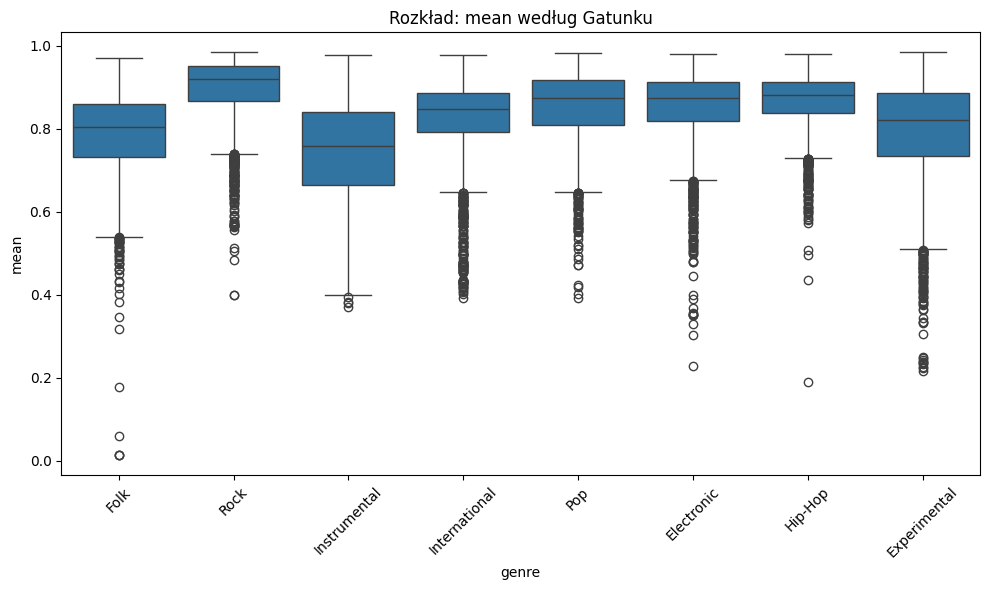

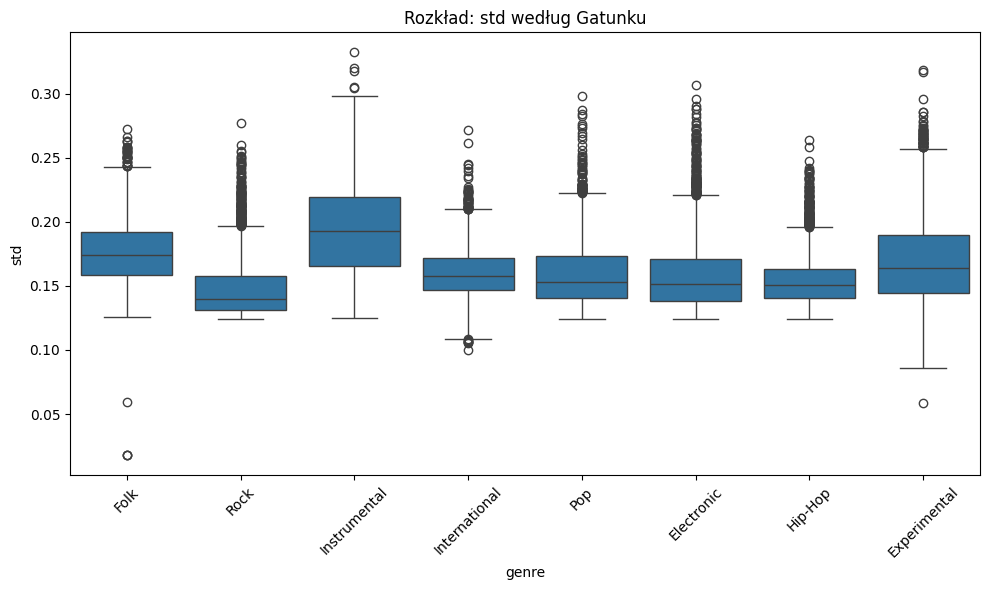

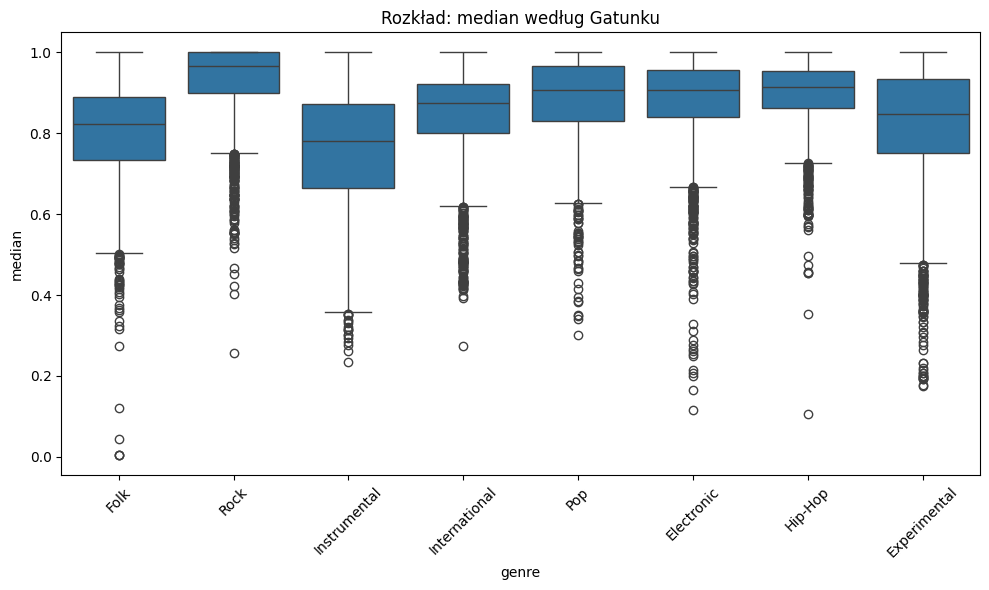

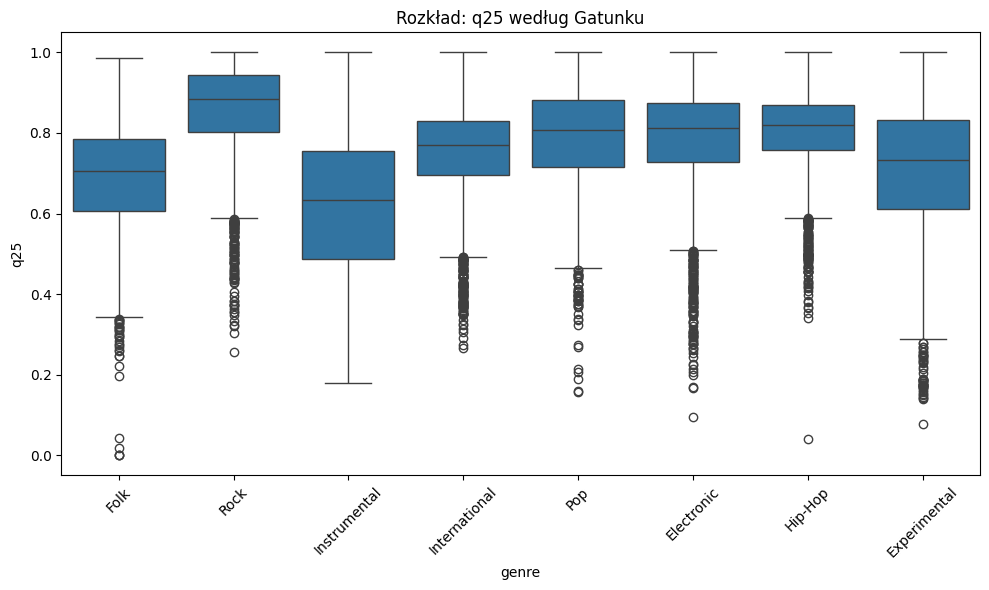

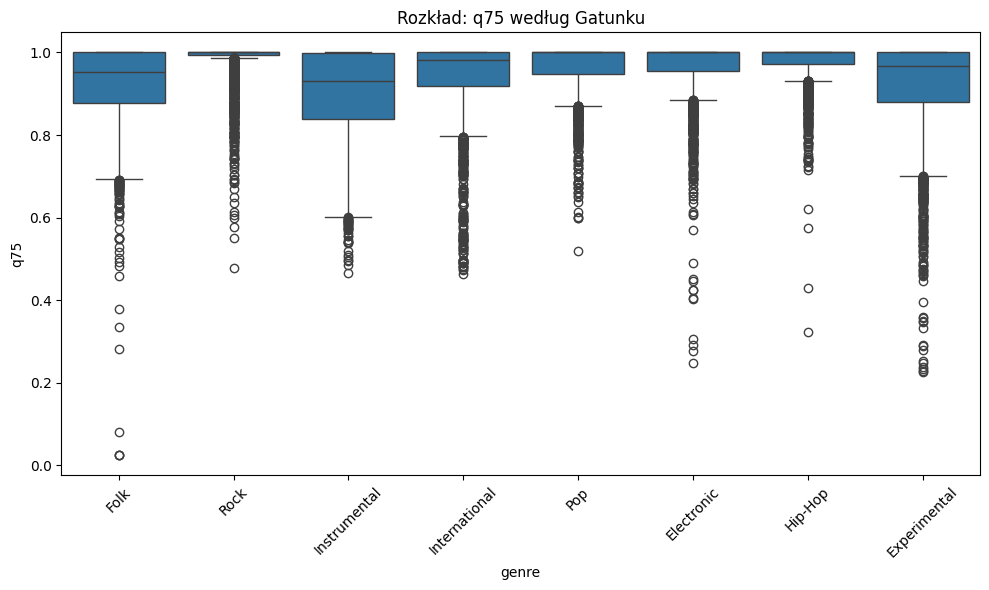

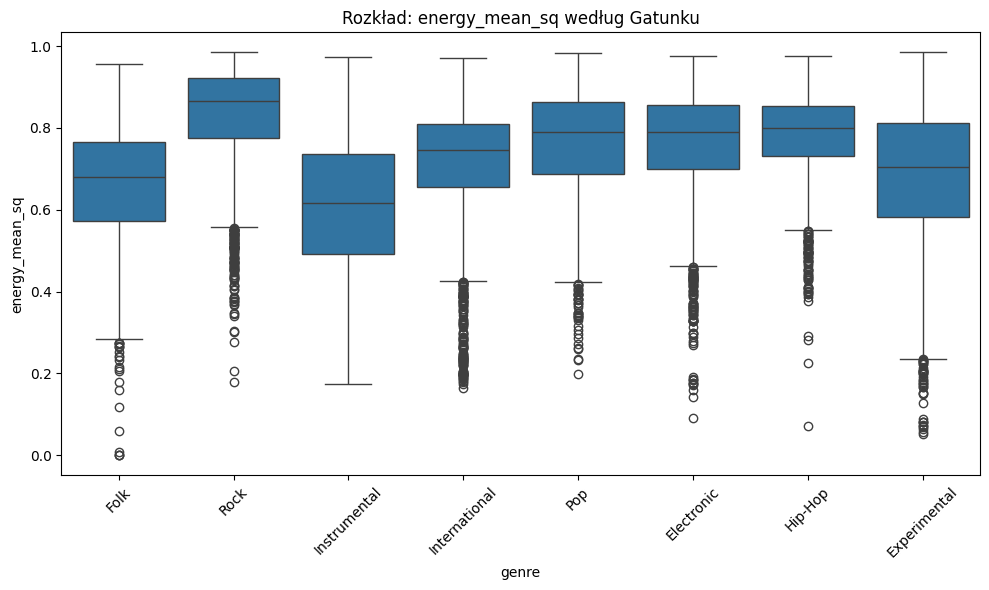

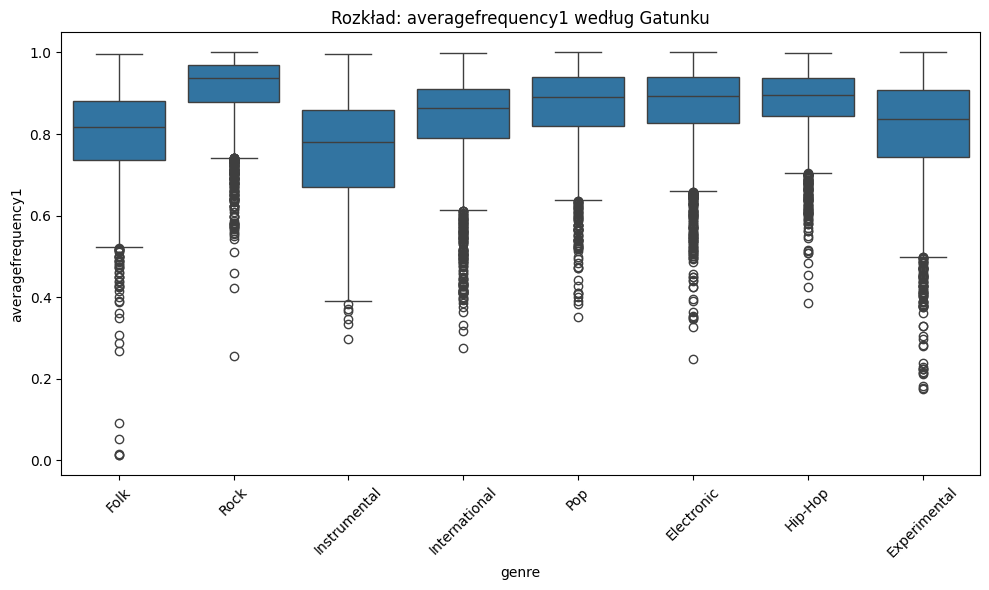

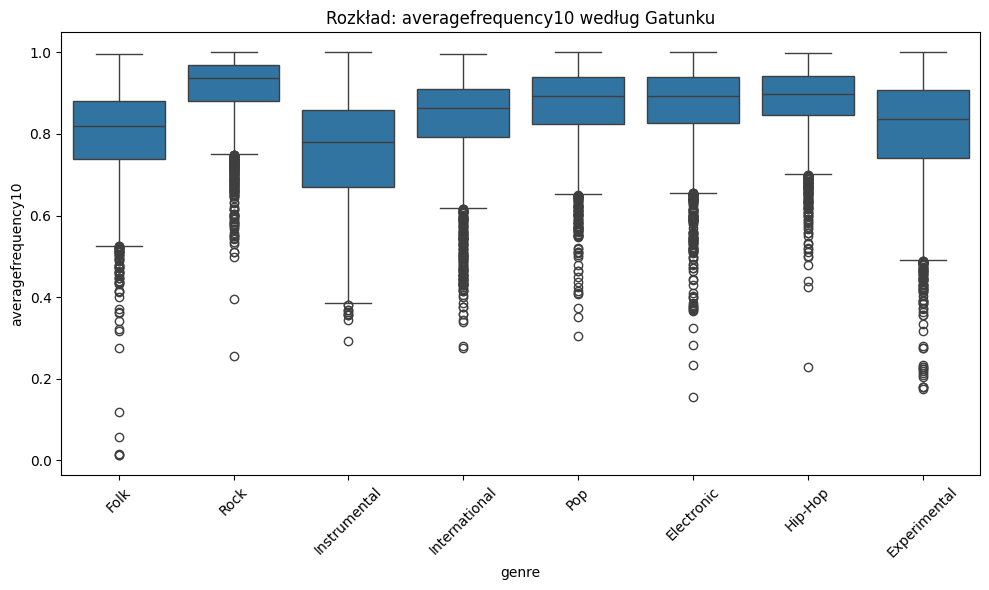

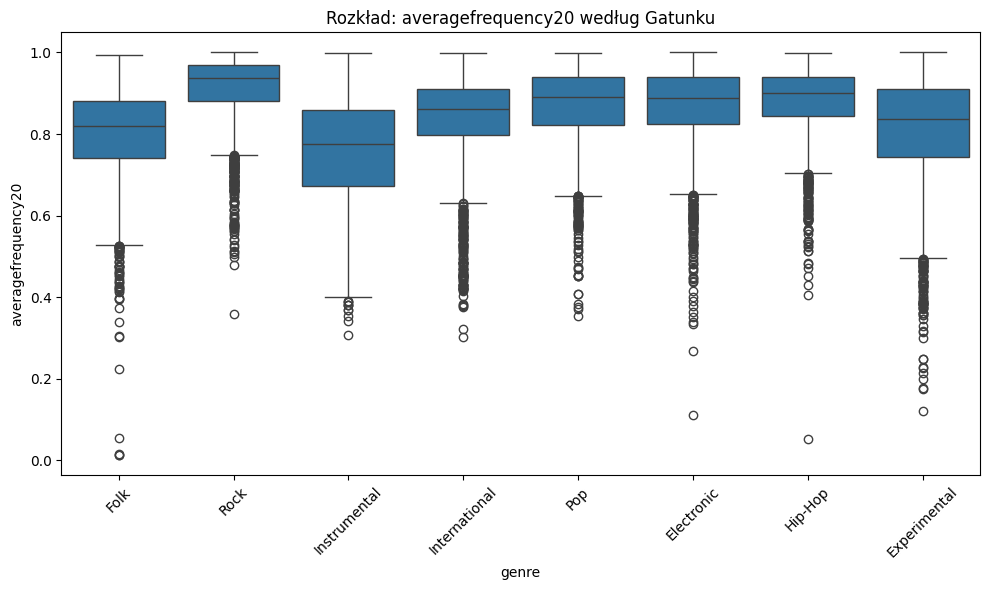

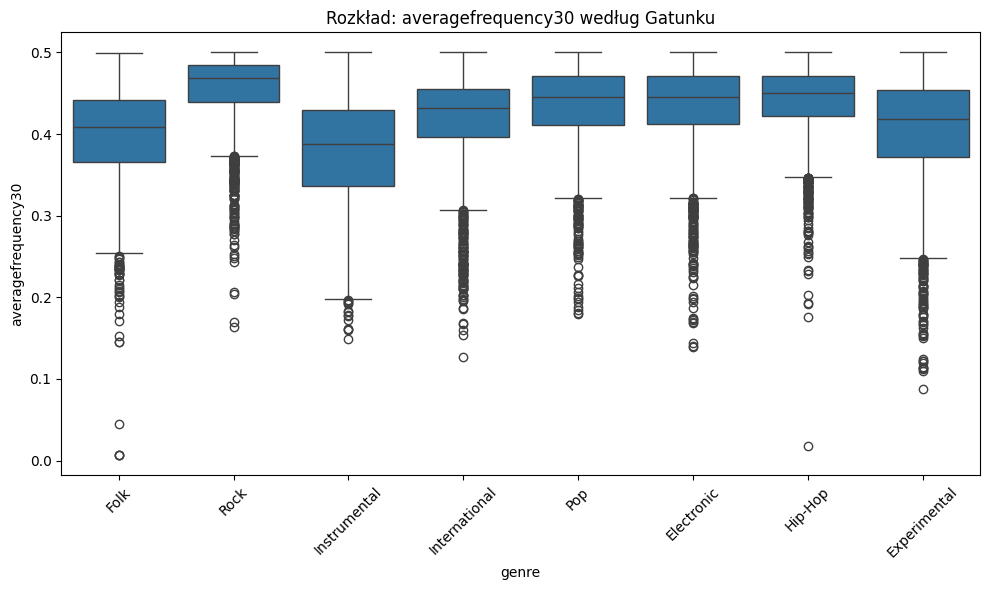

In [4]:

# 3. Poprawnośćdanych i outliers
# wybieramy kolumny numeryczne
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'track_id' in num_cols:
    num_cols.remove('track_id')

key_features = ['mean',
                 'std',
                   #'min', #bez różnic bez sensu
                     #'max', #to samo
                       'median', #podobny do średniej w sumie więć idk czy out
                         'q25',
                           'q75',
                             #'q90', #mało widać
                               'energy_mean_sq',
                                 #'sparsity_frac0', #nic nie widać sensownego
                                'averagefrequency1',
                                'averagefrequency10',
                                'averagefrequency20',
                                'averagefrequency30'
                                 ]
plot_features = [f for f in key_features if f in df.columns]


# Pętla generująca wykresy
for col in plot_features:
    # Tworzymy nową figurę dla każdego wykresu osobno
    plt.figure(figsize=(10, 6)) 
    
    # Rysujemy wykres
    sns.boxplot(x='genre', y=col, data=df)
    
    # Kosmetyka
    plt.title(f'Rozkład: {col} według Gatunku')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Wyświetlenie wykresu
    plt.show()
    


  

In [5]:
#WNIOSKI:

#Wykresy pudełkowe pokazują, że niektóre cechy różnicują gatunki lepiej niż inne.
#Przykład: mean i energy_mean_sq
#dla różnych gatunków (np. Instrumental ma wyższą energię i średnią niż Hip-Hop).

#Obserwacje odstające: Widoczne są liczne outliers,
#szczególnie w cechach takich jak std.
#Sugeruje to dużą zmienność utworów nawet wewnątrz jednego gatunku.

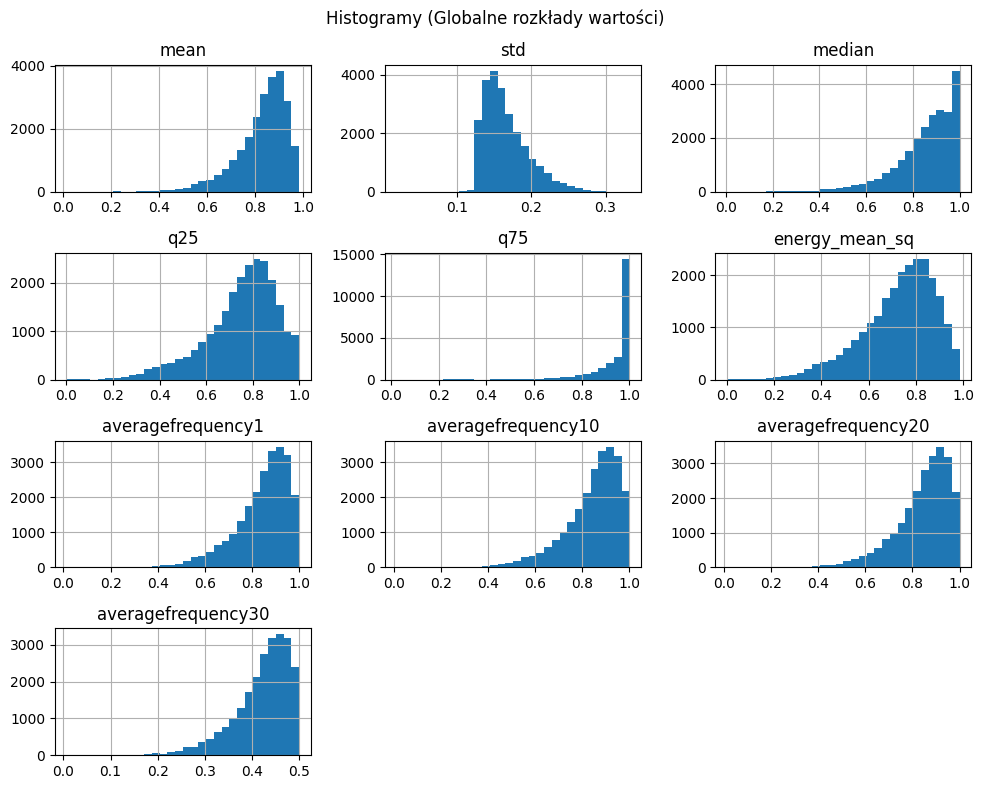

In [6]:
# 4. histogramy wartości dla globalnych
df[plot_features].hist(bins=30, figsize=(10, 8))
plt.suptitle('Histogramy (Globalne rozkłady wartości)')
plt.tight_layout()


In [7]:
#Histogramy: Globalne rozkłady cech są często niesymetryczne (skośne),
#  co sugeruje, że w docelowym modelu warto zastosować będzie normalizację (np. StandardScaler),
# co uwzględnimy w takim razie w teście dla kNNa

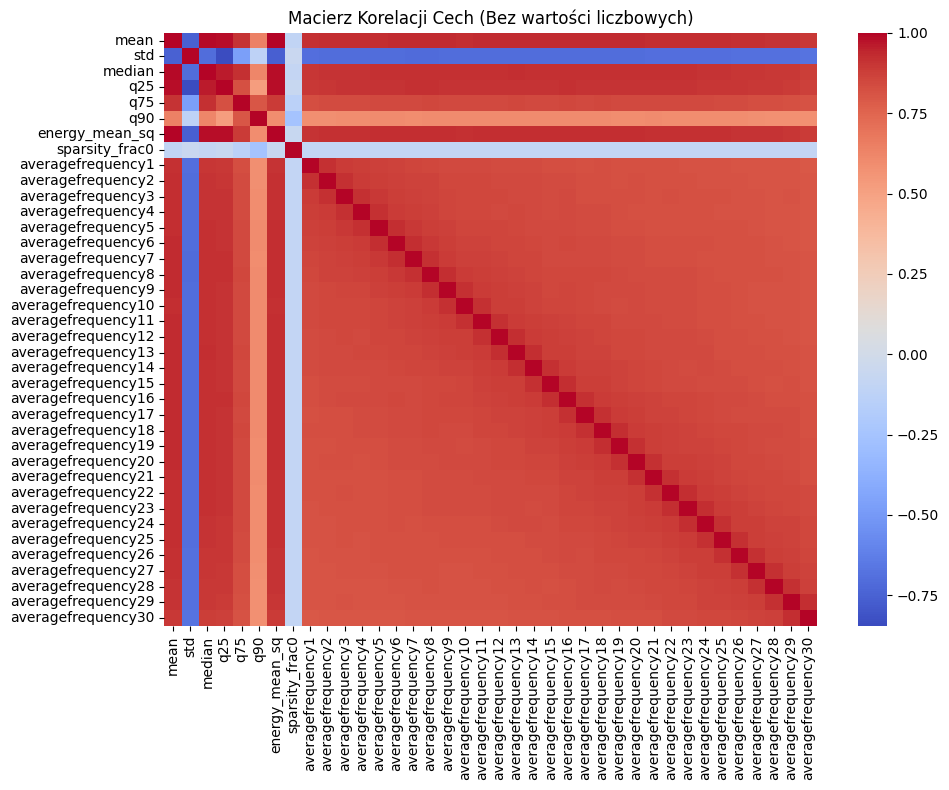

In [9]:
# 5. Correlation Matrix

# Usuwamy 'min' (bo jest stała) oraz 'track_id'
cols_to_drop = ['min']
# Sprawdzamy, czy kolumny istnieją przed usunięciem
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# Wybieramy tylko numeryczne kolumny i usuwamy te niechciane
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=existing_cols_to_drop)

# Generowanie macierzy korelacji
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()

# Rysowanie mapy ciepła
sns.heatmap(corr, annot=False, cmap='coolwarm')

plt.title('Macierz Korelacji Cech (Bez wartości liczbowych)')
plt.tight_layout()
plt.show()

In [ ]:
#Występuje silna współliniowość między niektórymi cechami.

#Korelacja bliska 1.0 występuje między mean, median, q25, q75 oraz energy_mean_sq.

#Oznacza to, że wiele z tych cech niesie tę samą informację.
#W finalnym modelu można rozważyć redukcję wymiarowości (PCA)
#lub usunięcie skorelowanych kolumn, aby uprościć model

Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- NAJLEPSZE PARAMETRY ---
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Best CV score (średnia z walidacji): 0.2601

--- FINAL REPORT (Zbiór testowy) ---
Test Accuracy: 0.2552
               precision    recall  f1-score   support

   Electronic       0.22      0.09      0.12       899
 Experimental       0.21      0.29      0.24       899
         Folk       0.21      0.23      0.22       900
      Hip-Hop       0.51      0.08      0.14       896
 Instrumental       0.28      0.60      0.38       899
International       0.24      0.15      0.18       900
          Pop       0.20      0.11      0.14       899
         Rock       0.30      0.50      0.38       899

     accuracy                           0.26      7191
    macro avg       0.27      0.26      0.23      7191
 weighted avg       0.27      0.26      0.23      7191



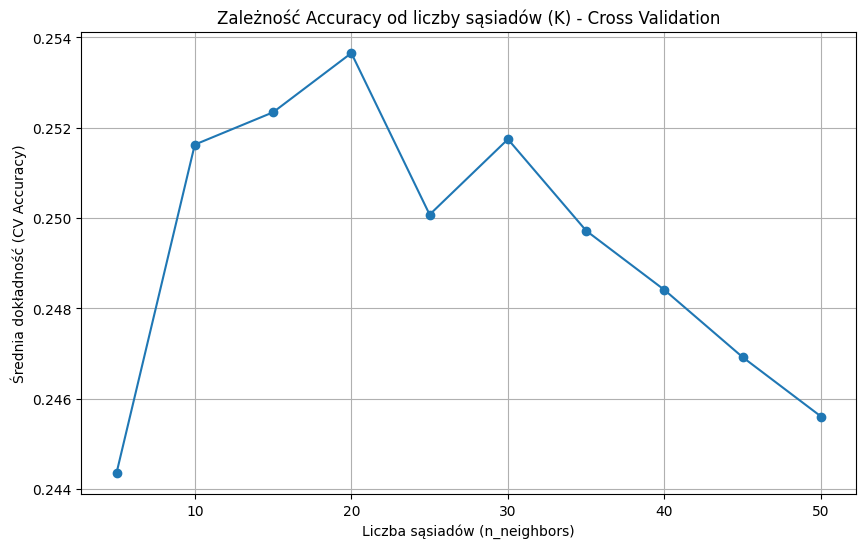

In [10]:
###znajdźmy wstępnie 'sensownego' kNNa i sprawdźmy jak sobie radzi

cols_to_drop = ['track_id', 'min'] 
# Upewniamy się, że usuwamy tylko te, które istnieją
existing_drop = [c for c in cols_to_drop if c in df.columns]
X = df.drop(columns=['genre'] + existing_drop)
y = df['genre']
# Encoding etykiet
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Podział na zbiór treningowy i ostateczny testowy
# Walidację krzyżową będziemy robić na X_train_val
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=123, stratify=y_encoded)

#Budowa Pipeline'u
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

#Definicja siatki parametrów
param_grid = {
    'knn__n_neighbors': list(range(5, 55, 5)),
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

#Uruchomienie GridSearchCV z Walidacją Krzyżową
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_val, y_train_val)

#wyniki
print("\n--- NAJLEPSZE PARAMETRY ---")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score (średnia z walidacji): {grid_search.best_score_:.4f}")

#miara na testowym
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- FINAL REPORT (Zbiór testowy) ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# (Opcjonalnie) Wizualizacja wyników dla n_neighbors (dla domyślnych wag i metryki)
results = pd.DataFrame(grid_search.cv_results_)
# Filtrujemy tylko dla wariantu uniform/euclidean żeby wykres był czytelny
subset = results[
    (results['param_knn__weights'] == 'uniform') & 
    (results['param_knn__metric'] == 'euclidean')
]

plt.figure(figsize=(10, 6))
plt.plot(subset['param_knn__n_neighbors'], subset['mean_test_score'], marker='o')
plt.title('Zależność Accuracy od liczby sąsiadów (K) - Cross Validation')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Średnia dokładność (CV Accuracy)')
plt.grid(True)
plt.show()

In [11]:
#Dokładność (Accuracy): ~25%
#Punkt odniesienia (losowy): Przy 8 klasach losowe zgadywanie dałoby wynik ok. 12.5%.

#Wniosek: Cechy statystyczne zawierają pewien sygnał (wynik jest lepszy od losowego),
#ale 25% to wciąż niski wynik. Zadanie klasyfikacji gatunku wyłącznie na podstawie prostych
#statystyk (średnia, mediana ze spektrogramu) byłoby trudne.

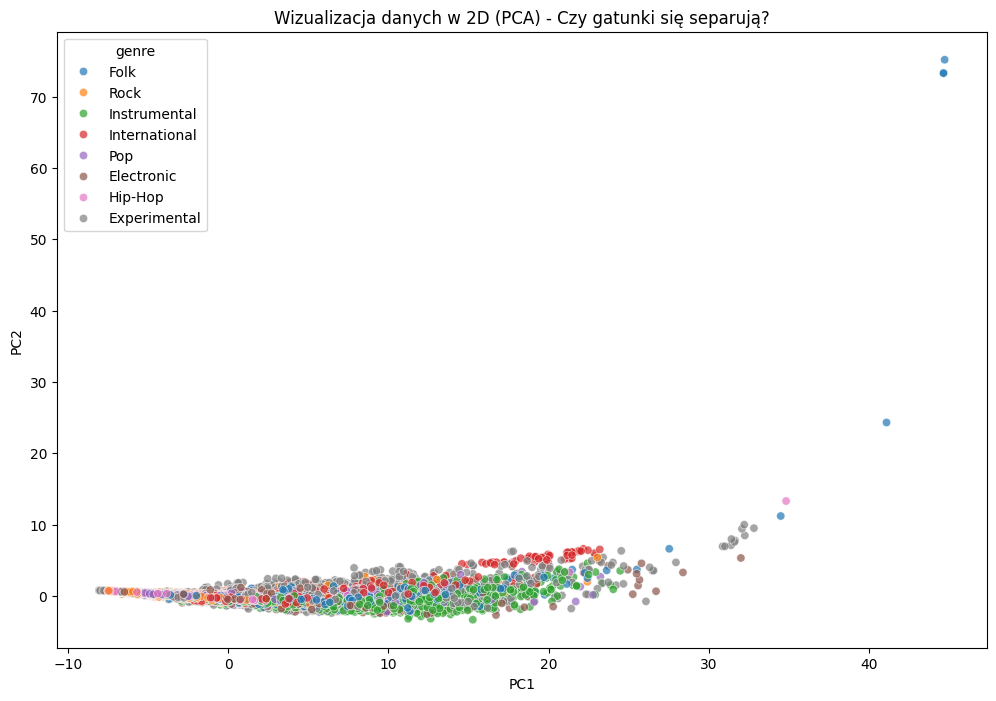

Wyjaśniona wariancja przez 2 komponenty: 85.93%


In [12]:
#Sprawdźmy dodatkowo PCA, aby potwierdzić, że nasze zadanie nie jest takie proste
# i będziemy potrzebować czegoś ambitniejszego

from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X to Twoje cechy bez kolumn-śmieci

# Redukcja do 2 wymiarówaby zobaczyć lepiej
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['genre'] = y.values # y to oryginalne etykiety gatunków

# Wykres
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='genre', data=df_pca, alpha=0.7, palette='tab10')
plt.title('Wizualizacja danych w 2D (PCA) - Czy gatunki się separują?')
plt.show()

# Wyjaśniona wariancja (ile informacji zachowaliśmy)
print(f"Wyjaśniona wariancja przez 2 komponenty: {sum(pca.explained_variance_ratio_):.2%}")

In [ ]:
#punkty kompletnie wymieszane - faktycznie proste statystyki w
#takim problemie zdecydowanie nie wystarczą